# 4.2 — Optimisation des prix  💰
**Projet Teranga Market — Partie 4 (Modeles)**

## Objectif
Trouver, pour chaque categorie, le **prix qui maximise la MARGE** (pas seulement le chiffre d'affaires).

## Les 2 idees cles
1. **Elasticite-prix de la demande** : quand le prix baisse de X %, de combien la quantite vendue augmente-t-elle ?
   `E = (variation % de la quantite) / (variation % du prix)`. Pour un bien normal, E est **negatif**.
2. **On l'estime grace aux PROMOTIONS** : ce sont de vraies baisses de prix observees dans les donnees
   (prix normal vs prix promo -> variation de quantite). Une *experimentation naturelle*. 🎁

## Pourquoi maximiser la marge et pas le revenu ?
Si la demande est **elastique** (E < -1, ce qui est notre cas ~ -2,5), baisser le prix augmente le revenu
sans fin -> le revenu seul pousserait le prix vers 0 (absurde). La **marge** `(prix - cout) x quantite`,
elle, a un **maximum clair**. C'est l'objectif business pertinent.

## 1. Imports et configuration

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

RACINE = Path.cwd().parents[1] if Path.cwd().name == "pricing" else Path("D:/PROJET_FINAL")
DB = RACINE / "02_DONNEES" / "warehouse" / "teranga.duckdb"
EVAL = RACINE / "03_MODELES" / "evaluation"; EVAL.mkdir(exist_ok=True)
print("Entrepot :", DB, "| existe :", DB.exists())

Entrepot : d:\PROJET_FINAL\02_DONNEES\warehouse\teranga.duckdb | existe : True


## 2. Construire les donnees prix / quantite
Pour chaque **categorie**, on calcule — separement en **promo** et **hors promo** :
- la **demande quotidienne moyenne** (unites/jour),
- le **prix moyen paye** (pondere par les quantites),
- le **cout unitaire moyen** (pour la marge).

> Rappel (vu a l'exploration) : la promo ne change pas la taille du panier, mais le **nombre de ventes**.
> On raisonne donc sur la demande totale par jour.

In [2]:
con = duckdb.connect(str(DB), read_only=True)
g = con.execute("""
    SELECT p.categorie,
           (t.id_promo != 0)                                   AS a_promo,
           SUM(t.quantite)                                      AS qte,
           COUNT(DISTINCT CAST(t.date_vente AS DATE))           AS njours,
           SUM(t.quantite * t.prix_unitaire)*1.0/SUM(t.quantite) AS prix,
           SUM(t.quantite * p.cout_unitaire)*1.0/SUM(t.quantite) AS cout
    FROM transactions t JOIN produits p ON t.id_produit = p.id_produit
    GROUP BY 1, 2
""").fetchdf()
con.close()
g["qte_jour"] = g["qte"] / g["njours"]     # demande quotidienne moyenne
g.round(1)

,categorie,a_promo,qte,njours,prix,cout,qte_jour
0,Ordinateurs,False,5063.0,365,816976.8,547597.4,13.9
1,Objets connectes,True,3497.0,102,139885.1,123881.5,34.3
2,TV & image,False,5091.0,364,614355.1,422826.5,14.0
3,Smartphones & tablettes,True,12671.0,102,377537.4,328498.0,124.2
4,Ordinateurs,True,2761.0,102,619264.5,538977.1,27.1
5,Smartphones & tablettes,False,23335.0,365,486519.6,324188.2,63.9
6,TV & image,True,2761.0,102,473372.2,425264.8,27.1
7,Objets connectes,False,6776.0,365,182060.6,123221.5,18.6
8,Accessoires,False,30012.0,365,22798.4,15705.7,82.2
9,Audio,True,8108.0,102,93217.7,82245.4,79.5


## 3. Estimer l'elasticite par categorie
On compare l'etat **hors promo** (prix P0, quantite Q0) et **en promo** (prix P1, quantite Q1).

On utilise la forme **logarithmique** (elasticite d'arc), qui correspond a un modele a elasticite constante :
$$E = \frac{\ln(Q_1/Q_0)}{\ln(P_1/P_0)}$$

In [3]:
lignes = []
for cat, sub in g.groupby("categorie"):
    n  = sub[~sub["a_promo"]].iloc[0]   # hors promo
    pr = sub[ sub["a_promo"]].iloc[0]   # en promo
    P0, Q0 = n["prix"], n["qte_jour"]
    P1, Q1 = pr["prix"], pr["qte_jour"]
    E = np.log(Q1/Q0) / np.log(P1/P0)
    lignes.append({"categorie": cat, "P0_normal": round(P0), "P1_promo": round(P1),
                   "Q0_jour": round(Q0,1), "Q1_jour": round(Q1,1),
                   "cout": round(n["cout"]), "elasticite": round(E,2)})
elas = pd.DataFrame(lignes)
elas

,categorie,P0_normal,P1_promo,Q0_jour,Q1_jour,cout,elasticite
0,Accessoires,22798,17677,82.2,156.7,15706,-2.54
1,Audio,120887,93218,41.7,79.5,81783,-2.48
2,Gaming,208618,160013,17.4,34.1,143871,-2.53
3,Objets connectes,182061,139885,18.6,34.3,123222,-2.33
4,Ordinateurs,816977,619265,13.9,27.1,547597,-2.41
5,Smartphones & tablettes,486520,377537,63.9,124.2,324188,-2.62
6,TV & image,614355,473372,14.0,27.1,422827,-2.53


> ⚠️ **Limite honnete a mentionner en soutenance** : les promos tombent souvent en periode de forte demande
> (rentree, fetes...). Une partie de la hausse de quantite est donc *saisonniere*, pas seulement liee au prix.
> L'elasticite est donc une **estimation** (legerement surestimee), suffisante pour ce projet.

## 4. Prix optimal (maximisation de la marge)
Modele a elasticite constante : $Q(P) = Q_0 \left(\dfrac{P}{P_0}\right)^{E}$.

Marge : $M(P) = (P - c)\, Q(P)$. En annulant la derivee $M'(P)=0$, on obtient le **prix optimal** :
$$P^{*} = c \cdot \frac{E}{E+1}$$
(formule classique du *markup* ; valable quand la demande est elastique, $E < -1$).

In [4]:
def prix_optimal(c, E):
    """Prix qui maximise la marge (elasticite constante). Valide si E < -1."""
    if E >= -1:                 # demande inelastique -> pas d'optimum interieur
        return np.nan
    return c * E / (E + 1)

def marge_relative(P, P0, c, E):
    """Marge a un prix P, en indice base 100 = marge au prix actuel P0."""
    Q = (P / P0) ** E           # quantite relative (Q0 = 1)
    return (P - c) * Q

res = []
for _, r in elas.iterrows():
    P0, c, E = r["P0_normal"], r["cout"], r["elasticite"]
    Pstar = prix_optimal(c, E)
    M0     = marge_relative(P0,    P0, c, E)
    Mstar  = marge_relative(Pstar, P0, c, E)
    res.append({"categorie": r["categorie"], "prix_actuel": round(P0),
                "prix_optimal": round(Pstar),
                "variation_%": round((Pstar/P0 - 1)*100, 1),
                "gain_marge_%": round((Mstar/M0 - 1)*100, 1)})
optim = pd.DataFrame(res)
optim

,categorie,prix_actuel,prix_optimal,variation_%,gain_marge_%
0,Accessoires,22798,25905,13.6,4.0
1,Audio,120887,137042,13.4,3.5
2,Gaming,208618,237904,14.0,4.2
3,Objets connectes,182061,215870,18.6,5.9
4,Ordinateurs,816977,935964,14.6,3.9
5,Smartphones & tablettes,486520,524304,7.8,1.3
6,TV & image,614355,699185,13.8,4.0


## 5. Visualiser la courbe de marge (exemple)
On trace la marge en fonction du prix pour une categorie, et on repere l'optimum.

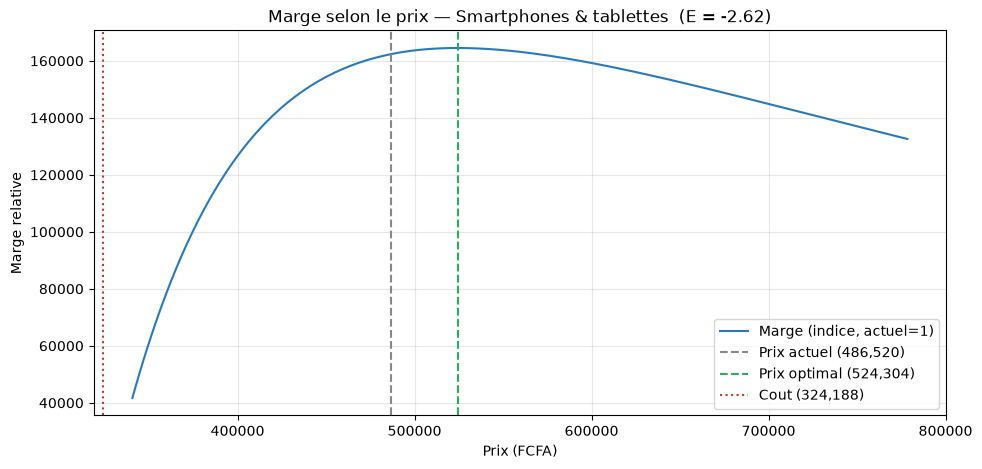

In [5]:
cat = "Smartphones & tablettes"
r = elas[elas["categorie"] == cat].iloc[0]
P0, c, E = r["P0_normal"], r["cout"], r["elasticite"]
Pstar = prix_optimal(c, E)

prix = np.linspace(0.7*P0, 1.6*P0, 200)
marge = [marge_relative(P, P0, c, E) for P in prix]

plt.figure(figsize=(11,5))
plt.plot(prix, marge, color="#2a7ab9", label="Marge (indice, actuel=1)")
plt.axvline(P0,    color="#888",    ls="--", label=f"Prix actuel ({P0:,.0f})")
plt.axvline(Pstar, color="#27ae60", ls="--", label=f"Prix optimal ({Pstar:,.0f})")
plt.axvline(c,     color="#c0392b", ls=":",  label=f"Cout ({c:,.0f})")
plt.title(f"Marge selon le prix — {cat}  (E = {E})")
plt.xlabel("Prix (FCFA)"); plt.ylabel("Marge relative"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 6. Conclusion ✅
On enregistre le tableau des prix recommandes (livrable).

In [6]:
optim.to_csv(EVAL / "metriques_pricing.csv", index=False)
print("Recommandations enregistrees dans :", EVAL / "metriques_pricing.csv")
optim

Recommandations enregistrees dans : d:\PROJET_FINAL\03_MODELES\evaluation\metriques_pricing.csv


,categorie,prix_actuel,prix_optimal,variation_%,gain_marge_%
0,Accessoires,22798,25905,13.6,4.0
1,Audio,120887,137042,13.4,3.5
2,Gaming,208618,237904,14.0,4.2
3,Objets connectes,182061,215870,18.6,5.9
4,Ordinateurs,816977,935964,14.6,3.9
5,Smartphones & tablettes,486520,524304,7.8,1.3
6,TV & image,614355,699185,13.8,4.0


**Ce qu'on retient :**
- La demande est **elastique** (E ~ -2,5) et coherente entre categories.
- En maximisant la **marge**, le modele recommande d'**ajuster les prix** (formule du markup optimal).
- Livrable conforme au sujet : *pricing optimisation simple (heuristique + simulation d'elasticite)*.

**Limite** : elasticite estimee via les promos (effet saisonnier partiellement confondu) — a affiner avec un
vrai test A/B en production.